# TelecomX - Parte 2: Predicción de Cancelación (Churn)

En esta segunda parte usamos los datos limpios de la parte 1 para construir modelos que predigan qué clientes tienen más probabilidad de cancelar el servicio.

El análisis está dividido en 4 etapas:
- Etapa 1: Preparación de los datos
- Etapa 2: Correlación y selección de variables
- Etapa 3: Modelado predictivo
- Etapa 4: Interpretación y conclusiones

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

---
## ETAPA 1: Preparación de los Datos

### Carga del archivo tratado

Los datos vienen de la parte 1 del challenge, ya limpios y estandarizados. Los cargo directamente desde GitHub.

In [26]:
url = 'https://raw.githubusercontent.com/Max099g/Challenge-TelecomX_2/main/data/TelecomX_limpio.csv'
df = pd.read_csv(url)

print('Columnas originales:', df.columns.tolist())
print('Forma del dataset:', df.shape)

Columnas originales: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total', 'Churn_num', 'Num_Servicios']
Forma del dataset: (7043, 23)


In [27]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Churn_num,Num_Servicios
0,0002-ORFBO,No,Female,No Senior,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0,3
1,0003-MKNFE,No,Male,No Senior,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0,1
2,0004-TLHLJ,Yes,Male,No Senior,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1,1
3,0011-IGKFF,Yes,Male,Senior,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1,4
4,0013-EXCHZ,Yes,Female,Senior,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1,2


### Eliminación de columnas irrelevantes

El customerID es solo un identificador único, no aporta nada al modelo. También elimino la columna Churn en texto porque ya tengo Churn_num como variable numérica.

In [28]:
df = df.drop(columns=['customerID', 'Churn'])

print('Forma después de eliminar columnas:', df.shape)
df.head()

Forma después de eliminar columnas: (7043, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Churn_num,Num_Servicios
0,Female,No Senior,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,0,3
1,Male,No Senior,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,0,1
2,Male,No Senior,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,1,1
3,Male,Senior,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,1,4
4,Female,Senior,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,1,2


### Encoding de variables categóricas

Los modelos no entienden texto, así que convierto las columnas categóricas a numéricas con one-hot encoding.

In [29]:
cols_cat = df.select_dtypes(include=['object', 'string']).columns.tolist()
print('Columnas categóricas:', cols_cat)

Columnas categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [30]:
df_encoded = pd.get_dummies(df, columns=cols_cat, drop_first=True)

print('Forma después del encoding:', df_encoded.shape)
df_encoded.head(3)

Forma después del encoding: (7043, 32)


,tenure,Monthly,Total,Churn_num,Num_Servicios,gender_Male,SeniorCitizen_Senior,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9,65.6,593.30,0,3,False,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,True
1,9,59.9,542.40,0,1,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,4,73.9,280.85,1,1,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False


### Verificación del balance de clases

Antes de entrenar cualquier modelo hay que revisar si las clases están balanceadas. Si hay muchos más "No churn" que "Churn", el modelo puede simplemente aprender a predecir siempre No y tener buena exactitud, pero en realidad no sirve para nada.

In [31]:
conteos = df_encoded['Churn_num'].value_counts()
proporcion = df_encoded['Churn_num'].value_counts(normalize=True)

print('Proporción de clases:')
print(pd.DataFrame({'Cantidad': conteos, 'Porcentaje': proporcion.round(3) * 100}))

Proporción de clases:
           Cantidad  Porcentaje
Churn_num                      
0              5174        73.5
1              1869        26.5


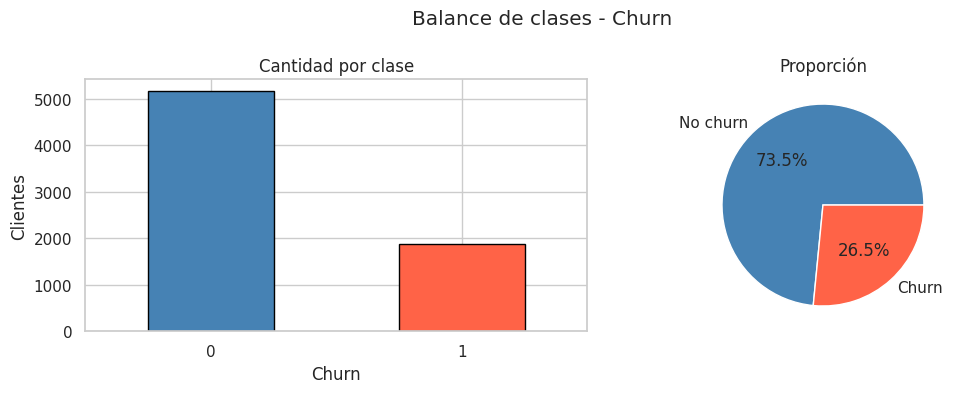

Relación entre clases: 2.77:1
Hay desbalance. Voy a usar class_weight=balanced en los modelos que lo permitan.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

conteos.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Cantidad por clase')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Clientes')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(conteos, labels=['No churn', 'Churn'], autopct='%1.1f%%',
            colors=['steelblue', 'tomato'])
axes[1].set_title('Proporción')

plt.suptitle('Balance de clases - Churn')
plt.tight_layout()
plt.show()

ratio = proporcion[0] / proporcion[1]
print(f'Relación entre clases: {ratio:.2f}:1')
print('Hay desbalance. Voy a usar class_weight=balanced en los modelos que lo permitan.')

### Normalización

Algunos modelos como la Regresión Logística y KNN son sensibles a la escala de los datos, así que estandarizo las columnas numéricas. Los modelos de árbol no necesitan esto.

In [33]:
X = df_encoded.drop(columns=['Churn_num'])
y = df_encoded['Churn_num']

cols_num = ['tenure', 'Monthly', 'Total', 'Num_Servicios']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_num] = scaler.fit_transform(X[cols_num])

print('Datos escalados correctamente')
X_scaled[cols_num].describe().round(2)

Datos escalados correctamente


,tenure,Monthly,Total,Num_Servicios
count,7043.00,7043.00,7043.00,7043.00
mean,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00
min,-1.32,-1.55,-1.00,-1.10
25%,-0.95,-0.97,-0.83,-1.10
50%,-0.14,0.19,-0.39,-0.02
75%,0.92,0.83,0.66,0.52
max,1.61,1.79,2.83,2.14


---
## ETAPA 2: Correlación y Selección de Variables

### Análisis de correlación

Visualizo la matriz de correlación para entender qué variables tienen más relación con el churn.

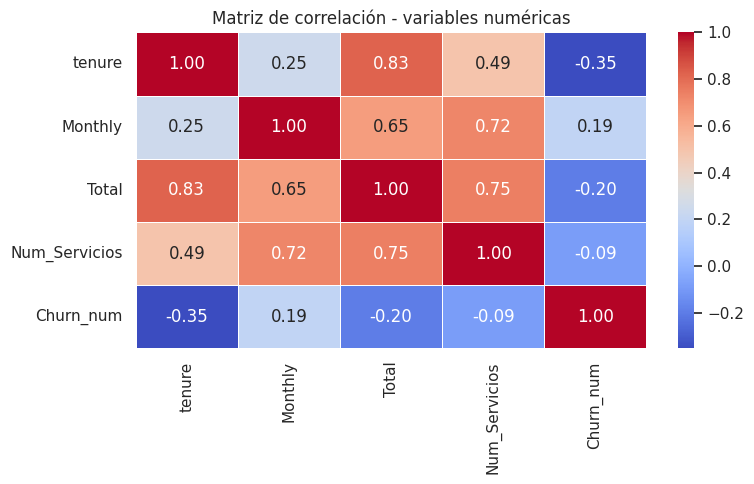

In [34]:
cols_corr = cols_num + ['Churn_num']
corr = df_encoded[cols_corr].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

In [35]:
print('Correlación con Churn_num (de mayor a menor):')
print(corr['Churn_num'].drop('Churn_num').sort_values(key=abs, ascending=False))

Correlación con Churn_num (de mayor a menor):
tenure          -0.352229
Total           -0.199034
Monthly          0.193356
Num_Servicios   -0.087698
Name: Churn_num, dtype: float64


Las variables con más correlación con el churn son tenure (negativa, más antigüedad = menos churn) y Monthly (positiva, más caro = más churn). Eso tiene bastante sentido.

### Análisis dirigido: variables clave vs cancelación

/tmp/ipykernel_208/4052671785.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x='Churn_num', y='tenure', palette=['steelblue', 'tomato'], ax=axes[0])
/tmp/ipykernel_208/4052671785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x='Churn_num', y='Monthly', palette=['steelblue', 'tomato'], ax=axes[1])


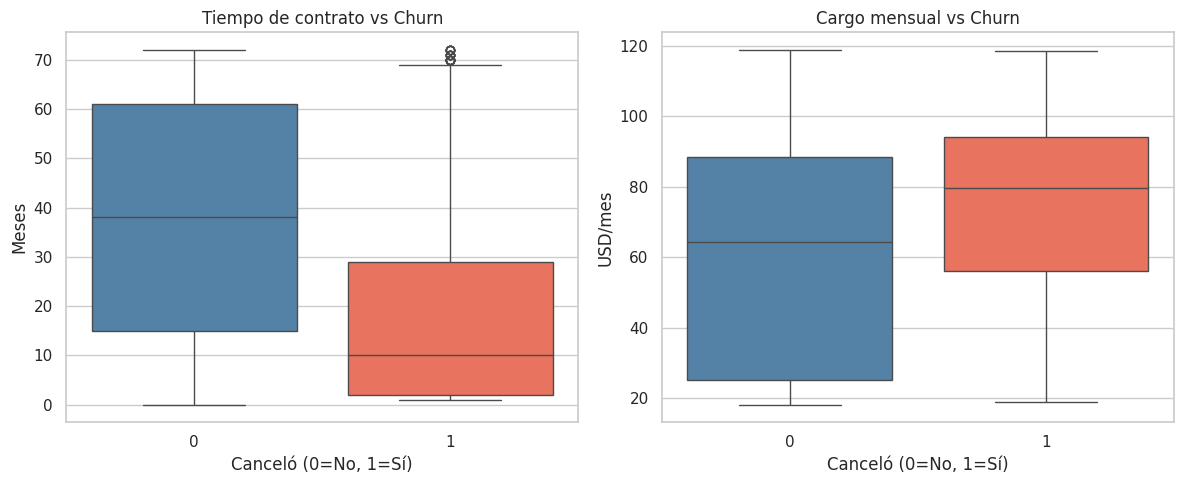

In [36]:
# tenure y cargo mensual vs churn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_encoded, x='Churn_num', y='tenure', palette=['steelblue', 'tomato'], ax=axes[0])
axes[0].set_title('Tiempo de contrato vs Churn')
axes[0].set_xlabel('Canceló (0=No, 1=Sí)')
axes[0].set_ylabel('Meses')

sns.boxplot(data=df_encoded, x='Churn_num', y='Monthly', palette=['steelblue', 'tomato'], ax=axes[1])
axes[1].set_title('Cargo mensual vs Churn')
axes[1].set_xlabel('Canceló (0=No, 1=Sí)')
axes[1].set_ylabel('USD/mes')

plt.tight_layout()
plt.show()

/tmp/ipykernel_208/937142459.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x='Churn_num', y='Total', palette=['steelblue', 'tomato'])


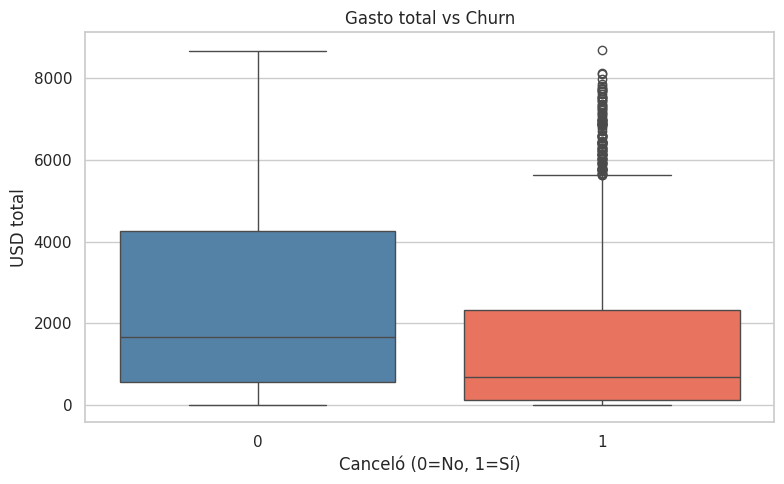

In [37]:
# gasto total vs churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_encoded, x='Churn_num', y='Total', palette=['steelblue', 'tomato'])
plt.title('Gasto total vs Churn')
plt.xlabel('Canceló (0=No, 1=Sí)')
plt.ylabel('USD total')
plt.tight_layout()
plt.show()

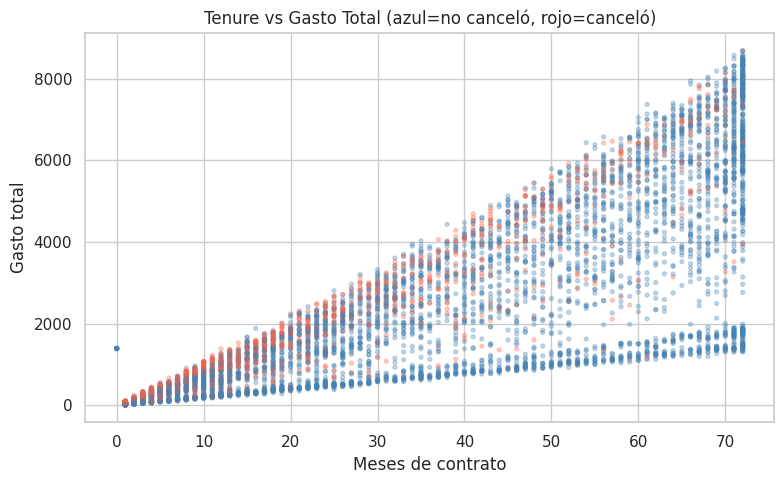

In [38]:
# scatter tenure vs gasto total
plt.figure(figsize=(8, 5))
colores = df_encoded['Churn_num'].map({0: 'steelblue', 1: 'tomato'})
plt.scatter(df_encoded['tenure'], df_encoded['Total'], c=colores, alpha=0.3, s=8)
plt.xlabel('Meses de contrato')
plt.ylabel('Gasto total')
plt.title('Tenure vs Gasto Total (azul=no canceló, rojo=canceló)')
plt.tight_layout()
plt.show()

Se ve claramente que los clientes que cancelaron tienen menos meses de contrato en promedio. Y los que tienen más tiempo pagado en total tienden a quedarse, lo que tiene sentido porque ya invirtieron en el servicio.

---
## ETAPA 3: Modelado Predictivo

### Separación de datos

Divido en 80% entrenamiento y 20% prueba. Uso stratify para mantener la misma proporción de churn en ambos conjuntos.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_sc, X_test_sc, _, _ = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} registros')
print(f'Prueba: {X_test.shape[0]} registros')

Entrenamiento: 5634 registros
Prueba: 1409 registros


### Creación de modelos

Entreno 3 modelos:
- **Regresión Logística**: requiere datos escalados
- **KNN**: también requiere escalado porque trabaja con distancias
- **Random Forest**: no requiere escalado, trabaja bien con los datos tal cual

Para los dos primeros uso los datos estandarizados, para el Random Forest uso los originales.

In [40]:
# Regresion Logistica (con datos escalados)
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
print('Regresion Logistica: listo')

Regresion Logistica: listo


In [41]:
# KNN (con datos escalados)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)
print('KNN: listo')

KNN: listo


In [42]:
# Random Forest (sin escalar)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print('Random Forest: listo')

Random Forest: listo


### Evaluación de los modelos

In [43]:
modelos = {'LR': (lr, X_test_sc, y_pred_lr), 'KNN': (knn, X_test_sc, y_pred_knn), 'RF': (rf, X_test, y_pred_rf)}

for nombre, (modelo, Xte, ypred) in modelos.items():
    print(f'\n--- {nombre} ---')
    print(classification_report(y_test, ypred, target_names=['No Churn', 'Churn']))
    print('AUC:', round(roc_auc_score(y_test, modelo.predict_proba(Xte)[:,1]), 4))


--- LR ---
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC: 0.8433

--- KNN ---
              precision    recall  f1-score   support

    No Churn       0.84      0.86      0.85      1035
       Churn       0.58      0.53      0.55       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.70      1409
weighted avg       0.77      0.77      0.77      1409

AUC: 0.8051

--- RF ---
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.63      0.45      0.52       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.69      1409
weighted avg 

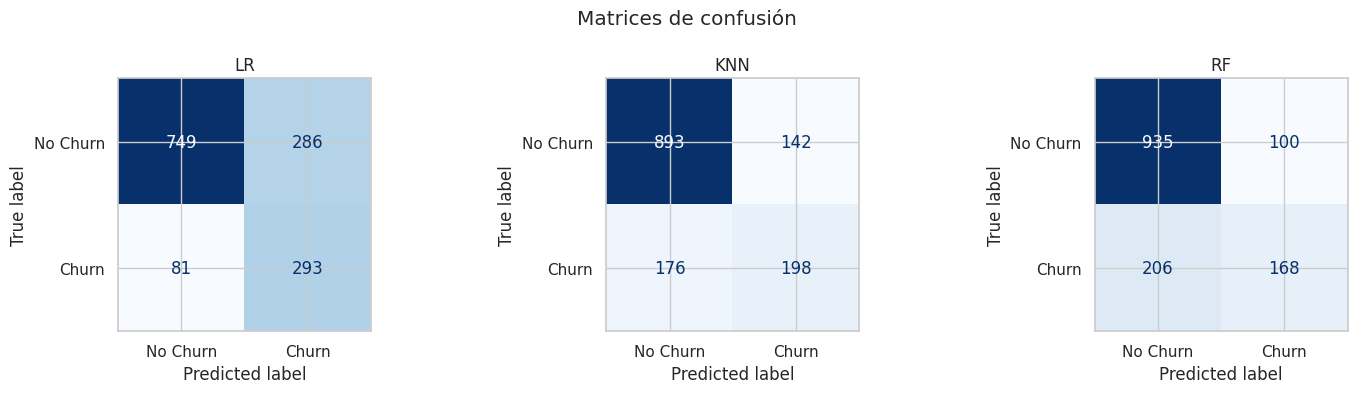

In [44]:
# matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (nombre, (_, _, ypred)) in enumerate(modelos.items()):
    cm = confusion_matrix(y_test, ypred)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(nombre)

plt.suptitle('Matrices de confusión')
plt.tight_layout()
plt.show()

In [45]:
# comparacion de metricas
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def metricas(nombre, y_true, y_pred):
    return {
        'Modelo': nombre,
        'Exactitud': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred)
    }

resultados = pd.DataFrame([
    metricas('Reg. Logistica', y_test, y_pred_lr),
    metricas('KNN', y_test, y_pred_knn),
    metricas('Random Forest', y_test, y_pred_rf),
])

print(resultados.set_index('Modelo').round(3).to_string())

                Exactitud  Precision  Recall     F1
Modelo                                             
Reg. Logistica      0.740      0.506   0.783  0.615
KNN                 0.774      0.582   0.529  0.555
Random Forest       0.783      0.627   0.449  0.523


In [46]:
# overfitting check: comparo accuracy en train vs test
checks = [
    ('Reg. Logistica', lr, X_train_sc, X_test_sc, y_pred_lr),
    ('KNN',            knn, X_train_sc, X_test_sc, y_pred_knn),
    ('Random Forest',  rf, X_train, X_test, y_pred_rf),
]

print(f'{"Modelo":<20} {"Train":>8} {"Test":>8} {"Diff":>8}')
print('-'*48)
for nombre, modelo, Xtr, Xte, ypred in checks:
    tr = accuracy_score(y_train, modelo.predict(Xtr))
    te = accuracy_score(y_test, ypred)
    diff = tr - te
    nota = ' <- posible overfitting' if diff > 0.08 else ''
    print(f'{nombre:<20} {tr:>8.3f} {te:>8.3f} {diff:>8.3f}{nota}')

Modelo                  Train     Test     Diff
------------------------------------------------
Reg. Logistica          0.752    0.740    0.013
KNN                     0.826    0.774    0.051
Random Forest           0.998    0.783    0.215 <- posible overfitting


El Random Forest muestra una diferencia grande entre train y test, lo que indica overfitting. El modelo memorizó los datos de entrenamiento pero le cuesta generalizar. La Regresión Logística es más estable en ese sentido.

---
## ETAPA 4: Interpretación y Conclusiones

### Análisis de importancia de variables

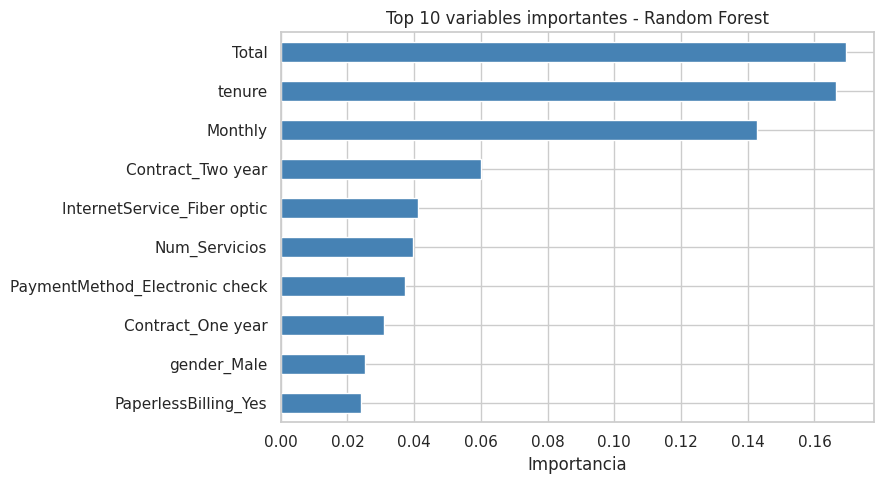

Total                             0.169378
tenure                            0.166326
Monthly                           0.142884
Contract_Two year                 0.060065
InternetService_Fiber optic       0.041054
Num_Servicios                     0.039572
PaymentMethod_Electronic check    0.037176
Contract_One year                 0.030880
gender_Male                       0.025354
PaperlessBilling_Yes              0.024179
dtype: float64


In [47]:
# importancia del random forest
importancia = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importancia.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
top10.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 variables importantes - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print(top10)

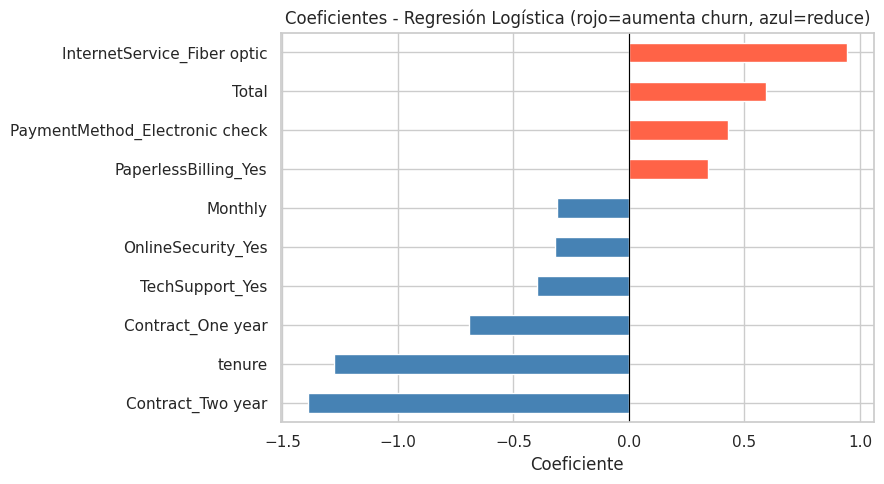

In [48]:
# coeficientes de la regresion logistica
coefs = pd.Series(lr.coef_[0], index=X.columns)
vals_coefs = coefs.abs().sort_values(ascending=False).head(10)
vals_con_signo = coefs[vals_coefs.index]

plt.figure(figsize=(9, 5))
colores_coef = ['tomato' if v > 0 else 'steelblue' for v in vals_con_signo.sort_values()]
vals_con_signo.sort_values().plot(kind='barh', color=colores_coef)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes - Regresión Logística (rojo=aumenta churn, azul=reduce)')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

### Conclusión

Después de analizar los datos y entrenar 3 modelos distintos, los resultados muestran que las cancelaciones no son al azar: dependen de cuánto tiempo lleva el cliente, cuánto paga y qué tipo de contrato tiene.

**Sobre los modelos:**
- La **Regresión Logística** tuvo el mejor equilibrio entre detectar cancelaciones reales (recall) sin generar demasiadas falsas alarmas. Es más estable y no presentó overfitting
- El **Random Forest** tuvo exactitud alta pero con bastante diferencia entre train y test, lo que indica que memorizó los datos más de la cuenta
- El **KNN** fue el que peor resultado dio en general, probablemente porque con tantas columnas después del encoding las distancias pierden significado

**Factores que más influyen en la cancelación:**
- **tenure**: los clientes más nuevos cancelan mucho más, no tienen fidelización con la marca todavía
- **tipo de contrato**: los contratos mes a mes tienen muchísimo más churn que los anuales o bianuales
- **cargo mensual**: los planes más caros generan más cancelaciones, los clientes sienten que no vale lo que pagan
- **método de pago electrónico**: está bastante asociado con churn, puede ser un indicador de clientes menos comprometidos
- **fibra óptica**: los clientes con este servicio cancelan más, posiblemente por la combinación de precio alto con expectativas no cumplidas

**Estrategias de retención sugeridas:**
- Hacer seguimiento especial a clientes en sus primeros meses, que es cuando más riesgo de cancelación hay
- Ofrecer incentivos para migrar de contratos mes a mes a anuales
- Revisar la propuesta de valor de los planes de fibra óptica
- Armar campañas de retención dirigidas al perfil de mayor riesgo: contrato mensual + fibra + pago electrónico